# Step 6: Evaluate Model 1 and Document Results

*Objective:* Load the best-performing Model 1 and evaluate it on the validation set.

1.  Load the best model weights from models/.
2.  Load the validation data.
3.  Calculate and save all performance metrics (Accuracy, Precision, Recall, F1-Score).
4.  Plot and save the Confusion Matrix.
5.  Load the training history from results/ and plot Loss & Accuracy curves.

In [5]:
import sys
from pathlib import Path

# Add the project root to Python path
project_root = Path.cwd().parent if 'notebooks' in str(Path.cwd()) else Path.cwd()
sys.path.insert(0, str(project_root))
sys.path.insert(0, str(project_root / 'src'))

print(f"Added to path: {project_root}")
print(f"Added to path: {project_root / 'src'}")

Added to path: d:\Major\FedMedSeg
Added to path: d:\Major\FedMedSeg\src


In [9]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import pandas as pd
from pathlib import Path
import sys
import numpy as np
import json
import matplotlib.pyplot as plt
from models import Model1_BasicCNN
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

# --- 1. CONFIGURATION ---
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR = Path("../models")
RESULTS_DIR = Path("../results")
SRC_DIR = Path("../src")

# --- Create results directory if it doesn't exist ---
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Add 'src' to system path
sys.path.append(str(SRC_DIR))

# --- IMPORT OUR CUSTOM CLASSES ---
try:
    from data_preprocessing import PneumoniaDataset
    from models import Model1_BasicCNN
    print("Successfully imported PneumoniaDataset and Model1_BasicCNN.")
except ImportError as e:
    print(f"ERROR: {e}")
    print("Please make sure 'src/dataset.py' and 'src/models.py' exist.")

# Paths to load from
MODEL_PATH = MODELS_DIR / "model_1_basic_cnn_best.pth"
HISTORY_PATH = RESULTS_DIR / "model_1_history.json"

# Paths to save to
METRICS_SAVE_PATH = RESULTS_DIR / "model_1_classification_report.txt"
CM_SAVE_PATH = RESULTS_DIR / "model_1_confusion_matrix.png"
PLOT_SAVE_PATH = RESULTS_DIR / "model_1_training_plots.png"

# Hyperparameters (must match training)
IMG_SIZE = 224
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Successfully imported PneumoniaDataset and Model1_BasicCNN.
Using device: cuda


## 1. Load Model and Data

In [10]:
# Define validation transform (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# Create validation dataset and loader
val_dataset = PneumoniaDataset(PROCESSED_DIR / "val_split.csv", transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize model
model = Model1_BasicCNN().to(device)

# Load the saved weights
try:
    model.load_state_dict(torch.load(MODEL_PATH))
    print(f"Successfully loaded model weights from {MODEL_PATH}")
except FileNotFoundError:
    print(f"ERROR: Model file not found at {MODEL_PATH}")
    print("Please run the '02-Model-1-Baseline.ipynb' notebook first.")

# Set model to evaluation mode
model.eval()

Successfully loaded model weights from ..\models\model_1_basic_cnn_best.pth


Model1_BasicCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=200704, out_features=64, bias=True)
  (relu3): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

## 2. Calculate Performance Metrics (Accuracy, Precision, Recall, F1-Score)

In [11]:
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in tqdm(val_loader, desc="Evaluating"): 
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        
        # Get predictions (sigmoid > 0.5)
        preds = torch.sigmoid(outputs.squeeze()) > 0.5
        
        # Move to CPU and store
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Convert to numpy arrays for sklearn
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# --- Calculate Metrics ---
print("\n--- Model 1 Evaluation Results ---\n")

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy: {accuracy:.4f}")

report = classification_report(y_true, y_pred, target_names=['Normal (0)', 'Pneumonia (1)'])
print(f"Classification Report:\n{report}")

# Save the report to the results folder
with open(METRICS_SAVE_PATH, 'w') as f:
    f.write(f"Accuracy: {accuracy:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(report)

print(f"Metrics saved to {METRICS_SAVE_PATH}")

Evaluating: 100%|██████████| 37/37 [00:16<00:00,  2.27it/s]


--- Model 1 Evaluation Results ---

Accuracy: 0.9343
Classification Report:
               precision    recall  f1-score   support

   Normal (0)       0.84      0.93      0.88       317
Pneumonia (1)       0.97      0.93      0.95       855

     accuracy                           0.93      1172
    macro avg       0.91      0.93      0.92      1172
 weighted avg       0.94      0.93      0.94      1172

Metrics saved to ..\results\model_1_classification_report.txt


## 3. Plot Confusion Matrix

Confusion matrix saved to ..\results\model_1_confusion_matrix.png


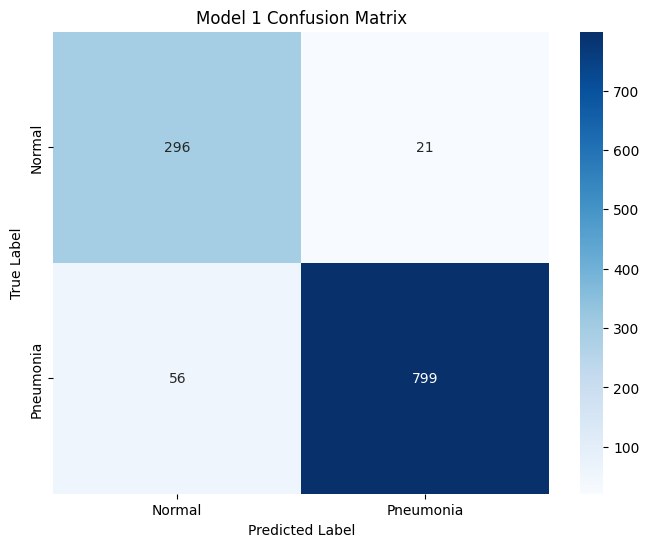

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Model 1 Confusion Matrix')

# Save the plot
plt.savefig(CM_SAVE_PATH)
print(f"Confusion matrix saved to {CM_SAVE_PATH}")
plt.show()

## 4. Plot Training History (Loss & Accuracy)

Loaded history from ..\results\model_1_history.json
Training plots saved to ..\results\model_1_training_plots.png


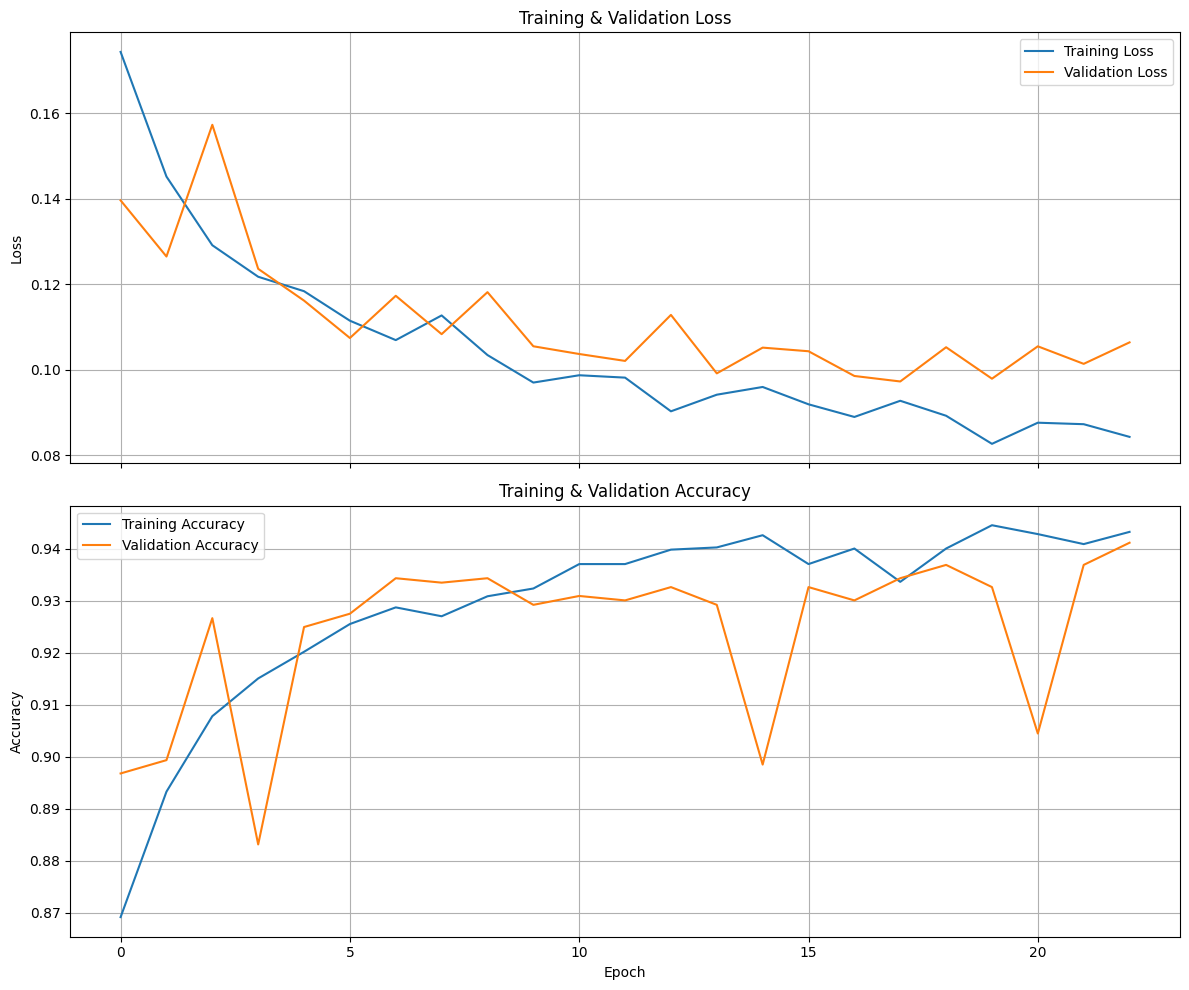

In [13]:
# Load the history file
try:
    with open(HISTORY_PATH, 'r') as f:
        history = json.load(f)
    print(f"Loaded history from {HISTORY_PATH}")

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot Loss
    ax1.plot(history['train_loss'], label='Training Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training & Validation Loss')
    ax1.legend()
    ax1.grid(True)

    # Plot Accuracy
    ax2.plot(history['train_acc'], label='Training Accuracy')
    ax2.plot(history['val_acc'], label='Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training & Validation Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    
    # Save the combined plot
    plt.savefig(PLOT_SAVE_PATH)
    print(f"Training plots saved to {PLOT_SAVE_PATH}")
    plt.show()

except FileNotFoundError:
    print(f"ERROR: History file not found at {HISTORY_PATH}")
    print("Please run the '02-Model-1-Baseline.ipynb' notebook first.")